We take 4 different approaches to conduct this real/fake news classification.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Imports

In [ ]:
import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize, WordPunctTokenizer
from nltk.corpus import stopwords, opinion_lexicon
from nltk import WordNetLemmatizer
from langdetect import detect
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from transformers import AutoTokenizer
from datasets import Dataset


## Importing the data

In [4]:
news = pd.read_csv("/content/drive/MyDrive/fake_real_news.csv")

In [5]:
news['text_final'] = news['title'] + ' ' + news['text']

Drop unneccesary columns.

In [6]:
df = news.drop(columns=['title','text','idd'])

Make binary classification labels

In [7]:
df['label'] = df['label'].apply(lambda x: 1 if x == 'FAKE' else 0)

Force as type string.

In [8]:
df["text_final"]=df["text_final"].astype(str)

Check languages (for the purposes of this project, we will only use english)

In [9]:
languages = []

for sentence in df["text_final"]:
    languages.append(detect(sentence))


df['language'] = languages

In [10]:
df=df[df['language']=='en']
df.shape

(4591, 3)

In [11]:
df

,label,text_final,language
0,0,‘A target on Roe v. Wade ’: Oklahoma bill maki...,en
1,0,Study: women had to drive 4 times farther afte...,en
2,0,"Trump, Clinton clash in dueling DC speeches Do...",en
3,0,Grand jury in Texas indicts activists behind P...,en
4,0,"As Reproductive Rights Hang In The Balance, De...",en
...,...,...,...
4589,1,Russia Calls the War Party's Bluff License DMC...,en
4590,1,Bernie Sanders: The Democratic primary gave me...,en
4591,1,"Pipeline Police Strip Search Native Girl, Then...",en
4592,1,Currency Crisis: Alasdair MacLeod On The Vexed...,en


In [12]:
base = df.copy()

### From here we have different preprocessing stages for each type.

# BOW approach

The Bag of Words (BOW) approach is a text representation technique that converts text data into numerical features based on word frequency. It disregards grammar and word order, focusing solely on the presence or absence of words in the text. In this project, we used TF-IDF (Term Frequency-Inverse Document Frequency) to weigh the importance of words and applied dimensionality reduction using SVD (Latent Semantic Analysis). Various machine learning models, including Logistic Regression, SVM, and Naive Bayes, were trained and evaluated.

### Final Results:
- **Logistic Regression**: Test Accuracy: 0.92, Test AUC: 0.91
- **SVM**: Test Accuracy: 0.93, Test AUC: 0.92
- **Naive Bayes**: Test Accuracy: 0.89, Test AUC: 0.88

In [13]:
import nltk
nltk.download('opinion_lexicon')
def Positive_words(text):
     pos_list=set(opinion_lexicon.positive())
     text = word_tokenize(text)
     return len([token for token in text if token in pos_list])

[nltk_data] Downloading package opinion_lexicon to /root/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!


In [14]:
def Negative_words(text):
     neg_list=set(opinion_lexicon.negative())
     text = word_tokenize(text)
     return len([token for token in text if token in neg_list])

In [15]:
def generateVariables (df):

     nbwords=[]
     exclamations=[]
     Pos_count=[]
     Neg_count=[]

     for sentence in df['text'] :
       nbwords.append(len(sentence.split()))
       exclamations.append(sentence.count('!'))
       Pos_count.append(Positive_words(sentence))
       Neg_count.append(Negative_words(sentence))

     df['WordCount']=nbwords
     df['ExclCount']=exclamations
     df['PosCount']=Pos_count
     df['NegCount']=Neg_count

     return df

In [17]:
import transformers
import datasets
from datasets import Dataset
import pandas as pd
import nltk
import re
import numpy as np
from sklearn.model_selection import train_test_split

wpt = nltk.WordPunctTokenizer()
nltk.download('stopwords')
stop_words = nltk.corpus.stopwords.words('english')  # initialize the stop word list


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [19]:
def normalize_document(doc):
    # lower case and remove special characters|whitespaces
    doc = re.sub(r"[^a-zA-Z\s]", '', doc, re.I|re.A)  # re.I ignores cases, re.A matches only ASCII characters
    doc = doc.lower()
    doc = doc.strip()

    # tokenize document
    tokens = wpt.tokenize(doc)

    # filter stopwords out of document
    filtered_tokens = [token for token in tokens if token not in stop_words]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]

    return " ".join(lemmatized_tokens)

normalize_corpus = np.vectorize(normalize_document)


In [20]:
df['text_final'] = df['text_final'].fillna('').astype(str)
df_norm_titles = pd.DataFrame({"norm_title":normalize_corpus(df['text_final'])})

df = df.join(df_norm_titles).drop(columns=['text_final'])

In [21]:
df = df.rename(columns={'label':'label','norm_title':'text'})

In [22]:
df.dtypes

,0
label,int64
language,object
text,object


In [23]:
df['text'] = df['text'].astype(str)

In [24]:
df.dtypes

,0
label,int64
language,object
text,object


In [25]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=['label','language'])
y=df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=53)

In [26]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [27]:
X_train=generateVariables(X_train)
X_test=generateVariables(X_test)

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD


tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),  # Unigrams + bigrams
    max_df=0.9,  # Ignore very common words
    min_df=5,  # Ignore rare words (only if large dataset)
    stop_words='english',  # Built-in stopword removal
    sublinear_tf=True,  # Apply sublinear TF scaling
    smooth_idf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train['text'])
X_test_tfidf = tfidf_vectorizer.transform(X_test['text'])

# Reduce dimensionality using SVD (Latent Semantic Analysis)
svd = TruncatedSVD(n_components=100)  # Reduce to 100 features
X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

log_reg = LogisticRegression(C=1.0, max_iter=1000)
log_reg.fit(X_train_svd, y_train)
y_pred_log = log_reg.predict(X_test_svd)


score = metrics.accuracy_score(y_test, y_pred_log)
auc = metrics.roc_auc_score(y_test, y_pred_log)

print('Test accuracy: '+ str(score))
print('Test AUC: '+ str(auc))

Test accuracy: 0.9216539717083787
Test AUC: 0.9216325660699062


In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'max_iter': [500, 1000, 2000]
}

grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_svd, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_svd)

score = metrics.accuracy_score(y_test, y_pred_best)
auc = metrics.roc_auc_score(y_test, y_pred_best)

print('Test accuracy: '+ str(score))
print('Test AUC: '+ str(auc))

Best Parameters: {'C': 10, 'max_iter': 500}
Test accuracy: 0.9379760609357998
Test AUC: 0.9379605948659657


In [31]:
from sklearn.svm import SVC
from sklearn import metrics

svm = SVC(kernel='linear', C=1.0)
svm.fit(X_train_svd, y_train)
y_pred_svm = svm.predict(X_test_svd)
score = metrics.accuracy_score(y_test, y_pred_svm)
auc = metrics.roc_auc_score(y_test, y_pred_svm)

print('Test accuracy: '+ str(score))
print('Test AUC: '+ str(auc))

Test accuracy: 0.9336235038084875
Test AUC: 0.9336056644880174


In [32]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'degree': [2, 3, 4]  # Only used for 'poly' kernel
}

# Initialize SVM
svm = SVC()

# Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Fit on training data
grid_search.fit(X_train_svd, y_train)

# Best hyperparameters
print("Best Parameters:", grid_search.best_params_)

# Evaluate on test data
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test_svd)

score = metrics.accuracy_score(y_test, y_pred)
auc = metrics.roc_auc_score(y_test, y_pred)

print('Test accuracy: '+ str(score))
print('Test AUC: '+ str(auc))

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Parameters: {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Test accuracy: 0.940152339499456
Test AUC: 0.940143980297433


In [33]:
# Import the necessary modules
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

# Instantiate a Multinomial Naive Bayes classifier: nb_classifier
nb_classifier = MultinomialNB()

# Fit the classifier to the training data
nb_classifier.fit(X_train_tfidf, y_train)
pred = nb_classifier.predict(X_test_tfidf)

# Calculate the accuracy and auc score: score
score = metrics.accuracy_score(y_test, pred)
auc = metrics.roc_auc_score(y_test, pred)

print('Test accuracy: '+ str(score))
print('Test AUC: '+ str(auc))

Test accuracy: 0.9096844396082698
Test AUC: 0.9096949891067537


In [34]:
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]  # Different levels of smoothing
}

# Initialize Naïve Bayes model
nb = MultinomialNB()

# Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(nb, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Fit on training data
grid_search.fit(X_train_tfidf, y_train)

# Best hyperparameters
print("Best Parameters:", grid_search.best_params_)

# Evaluate on test data
best_nb = grid_search.best_estimator_
y_pred = best_nb.predict(X_test_tfidf)


# Calculate the accuracy and auc score: score
score = metrics.accuracy_score(y_test, y_pred)
auc = metrics.roc_auc_score(y_test, y_pred)

print('Test accuracy: '+ str(score))
print('Test AUC: '+ str(auc))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Parameters: {'alpha': 0.01}
Test accuracy: 0.9129488574537541
Test AUC: 0.9129487543809794


# LSTM



The Long Short-Term Memory (LSTM) approach leverages a type of recurrent neural network (RNN) designed to handle sequential data effectively. In this project, the text data was preprocessed using tokenization, normalization, and padding. An LSTM-based model was built with embedding layers, dropout for regularization, and dense layers for classification. The model was trained using binary cross-entropy loss and the Adam optimizer.

### Results:
- **Test Accuracy**: 88.03% 
- The model demonstrated strong performance in classifying real and fake news, with effective handling of sequential dependencies in the text data.
- The model did initially overfit but measures were taken to account for that.

In [36]:
base

,label,text_final,language
0,0,‘A target on Roe v. Wade ’: Oklahoma bill maki...,en
1,0,Study: women had to drive 4 times farther afte...,en
2,0,"Trump, Clinton clash in dueling DC speeches Do...",en
3,0,Grand jury in Texas indicts activists behind P...,en
4,0,"As Reproductive Rights Hang In The Balance, De...",en
...,...,...,...
4589,1,Russia Calls the War Party's Bluff License DMC...,en
4590,1,Bernie Sanders: The Democratic primary gave me...,en
4591,1,"Pipeline Police Strip Search Native Girl, Then...",en
4592,1,Currency Crisis: Alasdair MacLeod On The Vexed...,en


In [37]:
nltk.download('stopwords')
wpt = WordPunctTokenizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [38]:
def normalize_document(doc):
    doc = re.sub(r"[^a-zA-Z\s]", '', doc, re.I|re.A)  # Remove special characters
    doc = doc.lower().strip()
    tokens = wpt.tokenize(doc)
    filtered_tokens = [token for token in tokens if token not in stop_words]
    return ' '.join(filtered_tokens)

In [39]:
df = base.copy()

In [40]:
df['text_final'] = df['text_final'].fillna('').astype(str)
df['text_final'] = df['text_final'].apply(normalize_document)

In [41]:
train, validate, test = np.split(df.sample(frac=1, random_state=42), [int(.6*len(df)), int(.8*len(df))])

/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [42]:
MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 200

keras_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
keras_tokenizer.fit_on_texts(train['text_final'])

X_train = pad_sequences(keras_tokenizer.texts_to_sequences(train['text_final']), maxlen=MAX_SEQUENCE_LENGTH)
X_val = pad_sequences(keras_tokenizer.texts_to_sequences(validate['text_final']), maxlen=MAX_SEQUENCE_LENGTH)
X_test = pad_sequences(keras_tokenizer.texts_to_sequences(test['text_final']), maxlen=MAX_SEQUENCE_LENGTH)

y_train, y_val, y_test = train['label'].values, validate['label'].values, test['label'].values


In [43]:
model = Sequential([
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=128, input_length=MAX_SEQUENCE_LENGTH),
    LSTM(64, return_sequences=True),
    Dropout(0.5),
    LSTM(32),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# Prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
model_ckpt = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=1)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, model_ckpt, reduce_lr],
    verbose=1
)

# Evaluation
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f'Test Accuracy: {accuracy:.4f}')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
86/87 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6389 - loss: 0.6240

87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.6415 - loss: 0.6214 - val_accuracy: 0.8780 - val_loss: 0.2991 - learning_rate: 0.0010
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9341 - loss: 0.1982 - val_accuracy: 0.8911 - val_loss: 0.3260 - learning_rate: 0.0010
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9863 - loss: 0.0674 - val_accuracy: 0.8922 - val_loss: 0.3380 - learning_rate: 2.0000e-04
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8691 - loss: 0.3222
Test Accuracy: 0.8585


In [44]:

# Load the best model
best_model = load_model('best_model.h5')


In [45]:
# Predict probabilities
y_pred_probs = best_model.predict(X_test)

# Convert probabilities to class labels (threshold = 0.5)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


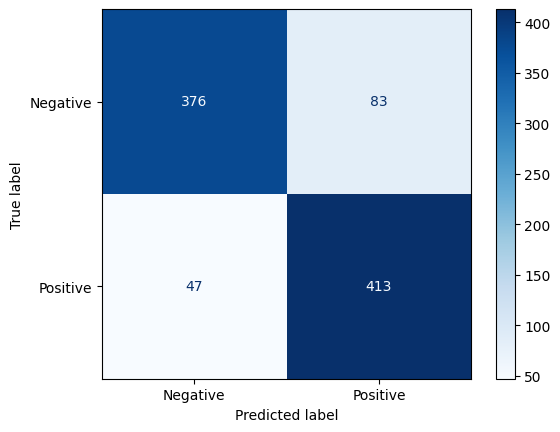

In [46]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap='Blues')


## Word Embeddings using Glove



The GloVe (Global Vectors for Word Representation) approach uses pre-trained word embeddings to represent text data as numerical vectors. In this implementation:
- Text data was preprocessed by removing special characters, converting to lowercase, and removing stopwords.
- Pre-trained GloVe embeddings (`glove.6B.100d.txt`) were loaded, and each text was represented as the average of its word vectors.
- A Support Vector Machine (SVM) classifier with a linear kernel was trained on the GloVe-based features.

#### Results:
- **Test Accuracy**: The SVM classifier achieved an accuracy of approximately 88.03% on the test set, demonstrating the effectiveness of GloVe embeddings in capturing semantic relationships for text classification.

In [48]:
df = pd.read_csv("/content/drive/MyDrive/fake_real_news.csv")

In [49]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [50]:
# Merge title and text into one column, drop 'idd' column
df['content'] = df['title'] + ' ' + df['text']
df = df.drop(columns=['idd'])

In [51]:
# Encode 'REAL' as 1 and 'FAKE' as 0
df['label'] = df['label'].map({'REAL': 0, 'FAKE': 1})
df['content'] = df['content'].astype(str)

In [52]:
stop_words = set(stopwords.words('english'))

In [53]:
def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove special characters and digits
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize and remove stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

In [54]:
df['processed_content'] = df['content'].apply(preprocess_text)

In [55]:
glove_path = r'/content/glove.6B.100d.txt'

In [56]:
# Load the GloVe model
glove_embeddings = {}
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = vector

In [57]:
def get_glove_vector(text):
    words = text.split()
    word_vectors = [glove_embeddings[word] for word in words if word in glove_embeddings]
    if len(word_vectors) == 0:
        return np.zeros(100)
    # Return the average of all word vectors
    return np.mean(word_vectors, axis=0)

In [58]:
X = np.array([get_glove_vector(text) for text in df['processed_content']])

In [59]:
y = df['label'].values

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Train a Support Vector Machine classifier
svm_model = SVC(kernel='linear')  # Linear kernel for better interpretability
svm_model.fit(X_train, y_train)

# Predict on the test set
y_pred_svm = svm_model.predict(X_test)

# Evaluate accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
accuracy_svm


0.8748639825897715

# Transfer Learning (via BERT)

The Transfer Learning approach using BERT (Bidirectional Encoder Representations from Transformers) leverages a pre-trained transformer model, `distilbert-base-uncased`, for text classification. The text data was tokenized, normalized, and processed into datasets for training, validation, and testing. The model was fine-tuned using a classification head for binary classification.

### Results:
- **Test AUC**: The fine-tuned BERT model achieved high accuracy of 98%, demonstrating its effectiveness in classifying real and fake news.
- **Efficiency**: The model effectively captured contextual relationships in the text, outperforming traditional methods by a significant margin.

In [63]:
news = pd.read_csv("/content/drive/MyDrive/fake_real_news.csv")

In [64]:
news['text_final'] = news['title'] + ' ' + news['text']

In [65]:
df = news.drop(columns=['title','text','idd'])

In [66]:
df['label'] = df['label'].apply(lambda x: 1 if x == 'FAKE' else 0)

In [67]:
news["text_final"]=news["text_final"].astype(str)

In [68]:
languages = []

# Loop over the sentences in the list and detect their language
for sentence in news["text_final"]:
    languages.append(detect(sentence))

# Assign the list to a new feature
news['language'] = languages

In [69]:
news=news[news['language']=='en']
news.shape

(4592, 6)

In [ ]:
# Initialize the WordPunctTokenizer for tokenizing text into words and punctuation
wpt = nltk.WordPunctTokenizer()

# Download the NLTK stopwords dataset
nltk.download('stopwords')

# Load the list of English stopwords
stop_words = nltk.corpus.stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [71]:
def normalize_document(doc):
    # lower case and remove special characters|whitespaces
    doc = re.sub(r"[^a-zA-Z\s]", '', doc, re.I|re.A)  # re.I ignores cases, re.A matches only ASCII characters
    doc = doc.lower()
    doc = doc.strip()

    # tokenize document
    tokens = wpt.tokenize(doc)

    # filter stopwords out of document
    filtered_tokens = [token for token in tokens if token not in stop_words]

    # re-create document from filtered tokens
    doc = ' '.join(filtered_tokens)

    return doc

normalize_corpus = np.vectorize(normalize_document)


In [ ]:
# Fill missing values in the 'text_final' column with an empty string and ensure the column is of type string
df['text_final'] = df['text_final'].fillna('').astype(str)

# Normalize the 'text_final' column using the normalize_corpus function and create a new DataFrame with the normalized text
df_norm_titles = pd.DataFrame({"norm_title": normalize_corpus(df['text_final'])})

# Join the normalized text DataFrame with the original DataFrame and drop the 'text_final' column
df = df.join(df_norm_titles).drop(columns=['text_final'])

In [73]:
df = df.rename(columns={'label':'label','norm_title':'text'})

In [ ]:
# Split the dataset into training, validation, and test sets
# Shuffle the dataset with a random state for reproducibility
# 60% of the data will be used for training, 20% for validation, and 20% for testing
train, validate, test = np.split(df.sample(frac=1, random_state=42), [int(.6*len(df)), int(.8*len(df))])

/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [75]:
train_ds = Dataset.from_pandas(train,split='train')
test_ds = Dataset.from_pandas(test,split='test')
validate_ds = Dataset.from_pandas(validate,split='validate')

In [ ]:
# Intialize the tokenizer for the DistilBERT model 
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# Preprocess the dataset using the tokenizer

def preprocessing_func(examples):
    return tokenizer(examples['text'],truncation=True)

In [ ]:
# Tokenize the datasets using the preprocessing function
tokenized_train = train_ds.map(preprocessing_func,batched=True)
tokenized_test = test_ds.map(preprocessing_func,batched=True)
tokenized_validate = validate_ds.map(preprocessing_func,batched=True)

Map:   0%|          | 0/2756 [00:00<?, ? examples/s]

Map:   0%|          | 0/919 [00:00<?, ? examples/s]

Map:   0%|          | 0/919 [00:00<?, ? examples/s]

In [ ]:

from transformers import DataCollatorWithPadding
# Create a data collator that will dynamically pad the inputs received, so that they all have the same length
# This is useful for batching the inputs together
data_collator = DataCollatorWithPadding(tokenizer=tokenizer,return_tensors='tf')
id2label = {0: 'False',1:'True'}
label2id = {'False':0 ,'True':1}

In [ ]:
from transformers import create_optimizer
import tensorflow as tf



batch_size = 16  # Number of samples per batch
num_epochs = 10  # Total number of epochs for training
batches_per_epoch = len(tokenized_train) // batch_size  # Calculate the number of batches per epoch
total_train_steps = int(batches_per_epoch * num_epochs)  # Total number of training steps

# Create an optimizer with a learning rate schedule
optimizer, schedule = create_optimizer(
    init_lr=2e-5,  # Initial learning rate
    num_warmup_steps=0,  # Number of warmup steps
    num_train_steps=total_train_steps  # Total number of training steps
)

In [ ]:
from transformers import TFAutoModelForSequenceClassification
# Load the pre-trained DistilBERT model for sequence classification
model = TFAutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased',num_labels= 2, id2label= id2label, label2id=label2id)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_projector.bias', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

In [82]:
tf_train_set = model.prepare_tf_dataset(tokenized_train, shuffle=True, batch_size=16,collate_fn=data_collator)

tf_val_set = model.prepare_tf_dataset(tokenized_validate, shuffle=True, batch_size=16,collate_fn=data_collator)

In [83]:
import tensorflow as tf
model.compile(optimizer=optimizer)

model.fit(x=tf_train_set,validation_data=tf_val_set, epochs=3)

Epoch 1/3
172/172 [==============================] - 200s 1s/step - loss: 0.3773 - val_loss: 0.1878
Epoch 2/3
172/172 [==============================] - 180s 1s/step - loss: 0.1671 - val_loss: 0.1781
Epoch 3/3
172/172 [==============================] - 178s 1s/step - loss: 0.0928 - val_loss: 0.1846


In [84]:
tf_test_set = model.prepare_tf_dataset(
    tokenized_test,
    shuffle=False,
    batch_size=16,
    collate_fn=data_collator,
)

In [ ]:
# Evaluate the model on the test set
import sklearn
import sklearn.metrics
from tensorflow.keras import activations

preds = model.predict(tf_test_set).logits
preds = activations.softmax(tf.convert_to_tensor(preds)).numpy()

y_t = np.array(test["label"])
y_s = np.array(preds[:,1])

sklearn.metrics.roc_auc_score(y_t, y_s)

58/58 [==============================] - 20s 317ms/step


np.float64(0.9823434687884814)